# New Section

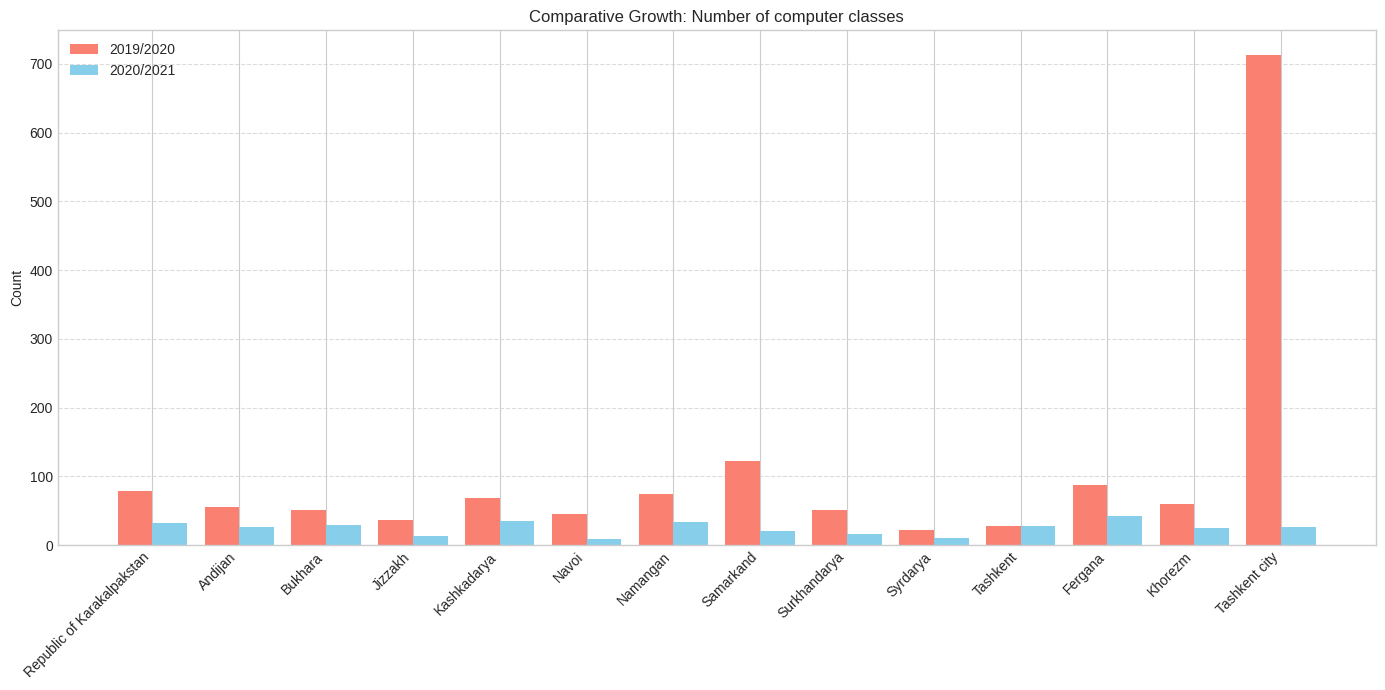

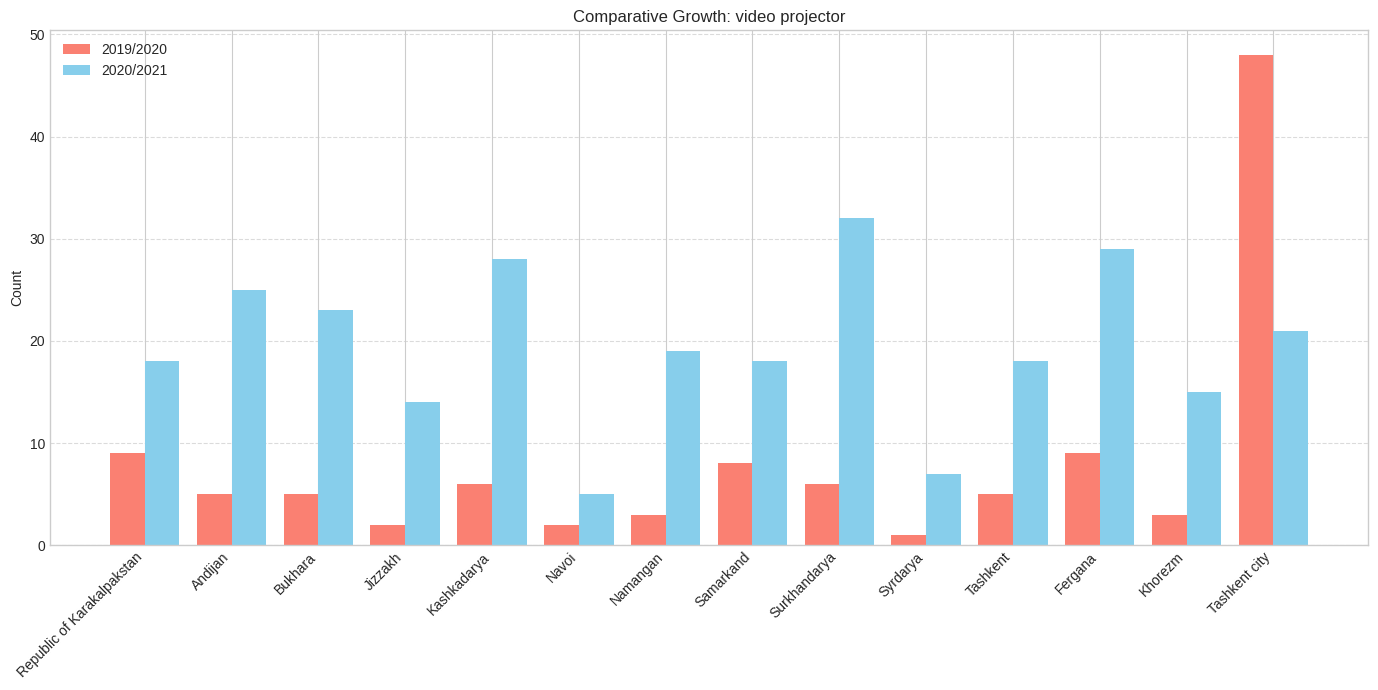

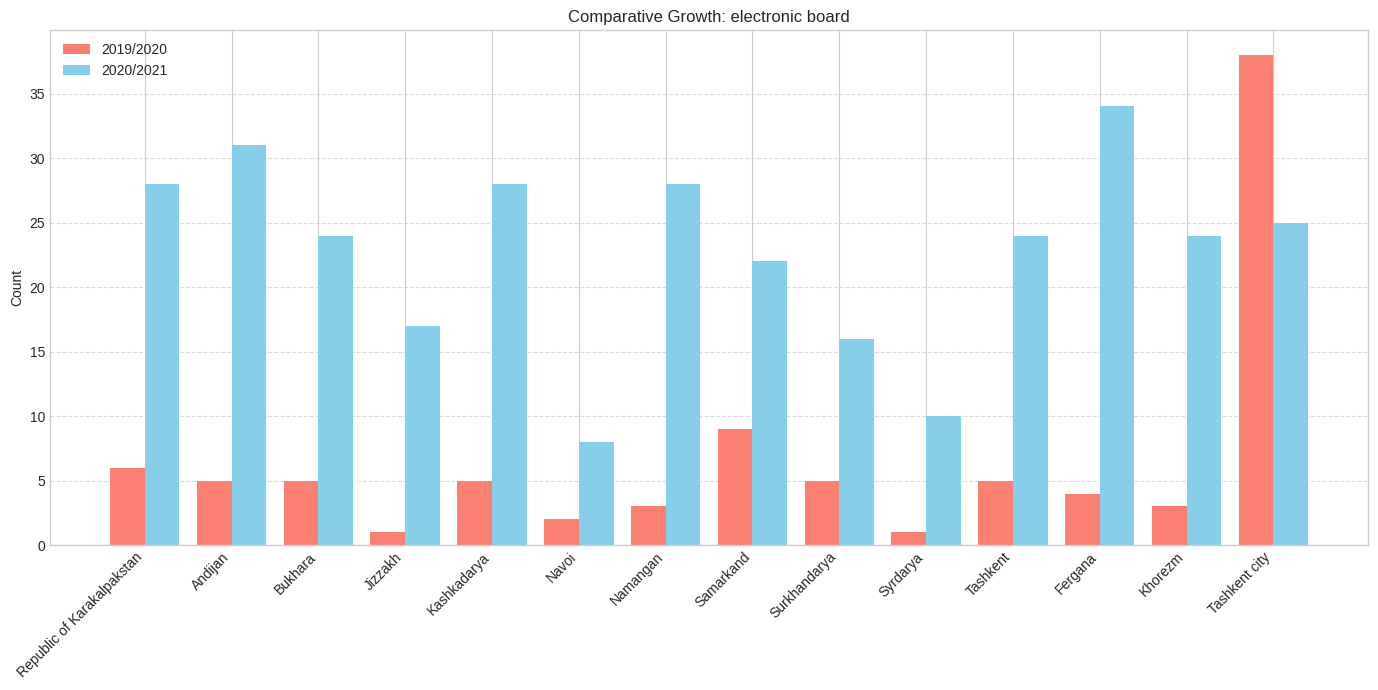

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

file_name = 'Info on Technology distribution csv.csv'

df = pd.read_excel(file_name)

if df is not None:
    df_filtered = df[df['Name of Territories'] != 'The Republic of Uzbekistan'] # Changed filter condition

    comparison_columns = [
        ('2019/2020 Number of computer classes', '2020/2021 Number of computer classes'),
        ('2019/2020 video projector', '2020/2021 video projector'),
        ('2019/2020 electronic board', '2020/2021 electronic board')
    ]

    for col_old, col_new in comparison_columns:
        plt.figure(figsize=(14, 7))
        x = range(len(df_filtered['Name of Territories']))

        plt.bar(x, df_filtered[col_old], width=0.4, label='2019/2020', color='salmon')
        plt.bar([i + 0.4 for i in x], df_filtered[col_new], width=0.4, label='2020/2021', color='skyblue')

        plt.xticks([i + 0.2 for i in x], df_filtered['Name of Territories'], rotation=45, ha='right')
        plt.title(f'Comparative Growth: {col_old.replace("2019/2020 ", "")}')
        plt.ylabel('Count')
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
else:
    print("Faylni ochishning imkoni bo'lmadi. Iltimos, fayl nomini tekshiring.")

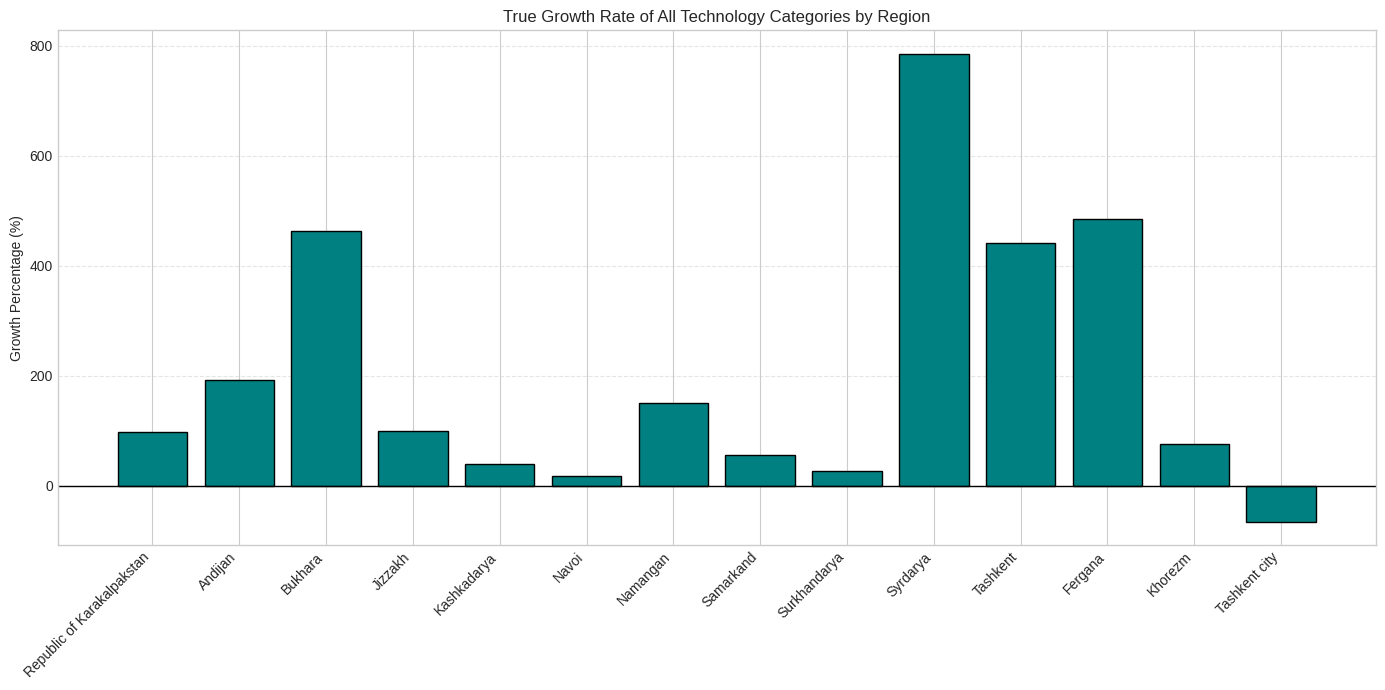

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'Info on Technology distribution csv.csv'
df = pd.read_excel(file_path)

df = df.dropna(subset=['Name of Territories'])
df = df[df['Name of Territories'] != 'The Republic of Uzbekistan']

numeric_cols = df.columns[2:12]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

cols_2019 = df.columns[2:7]
cols_2020 = df.columns[7:12]

df['Total_2019'] = df[cols_2019].sum(axis=1)
df['Total_2020'] = df[cols_2020].sum(axis=1)

df['Growth_Rate'] = ((df['Total_2020'] - df['Total_2019']) / df['Total_2019'].replace(0, float('inf'))) * 100

plt.figure(figsize=(14, 7))
plt.bar(df['Name of Territories'], df['Growth_Rate'], color='teal', edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title('True Growth Rate of All Technology Categories by Region')
plt.ylabel('Growth Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

           Name of Territories  Total_2019  Total_2020   Growth_Rate
1   Republic of Karakalpakstan           9         125   1288.888889
2                      Andijan           5         114   2180.000000
3                      Bukhara           5         309   6080.000000
4                      Jizzakh           2          33   1550.000000
5                  Kashkadarya           6          19    216.666667
6                        Navoi           2          36   1700.000000
7                     Namangan           3         117   3800.000000
8                    Samarkand          10         171   1610.000000
9                 Surkhandarya           7          16    128.571429
10                    Syrdarya           2         215  10650.000000
11                    Tashkent           5         174   3380.000000
12                     Fergana          10         571   5610.000000
13                     Khorezm           3          50   1566.666667
14               Tashkent city    

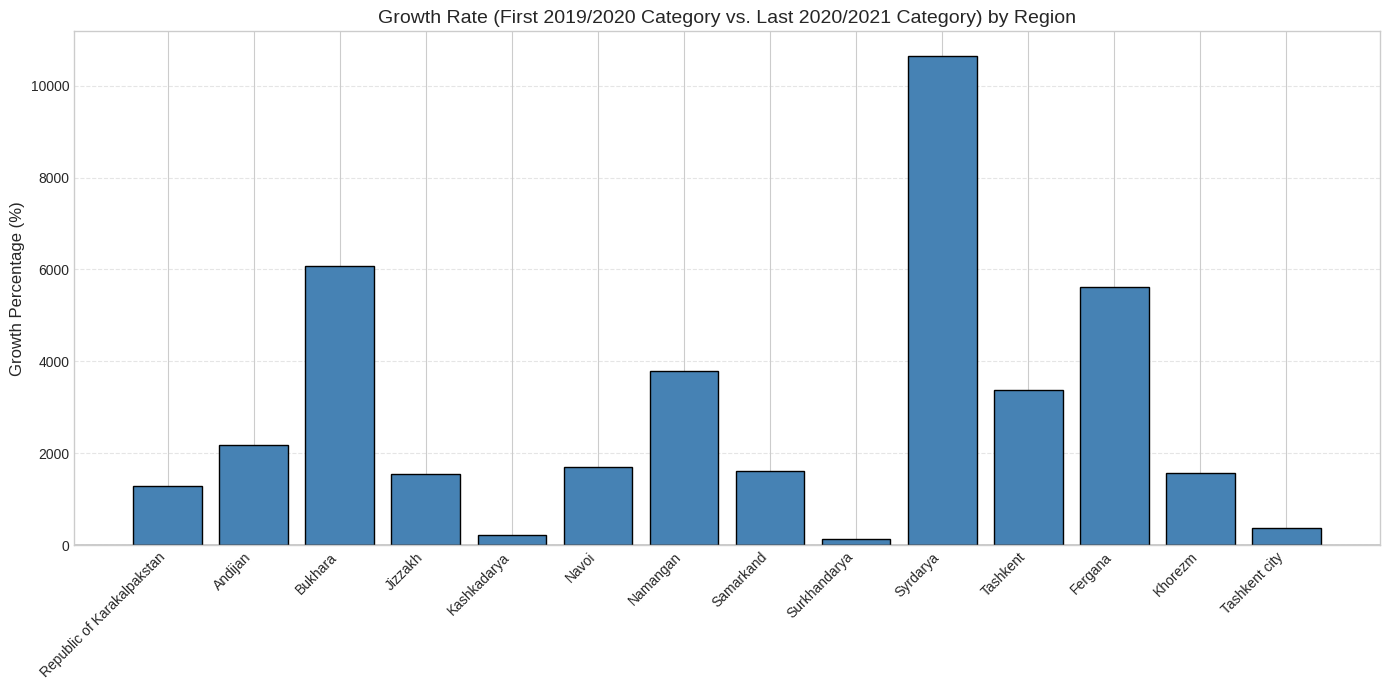

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

data_file = 'Info on Technology distribution csv.csv'
df = pd.read_excel(data_file)

df = df.dropna(subset=['Name of Territories'])
target_data = df[df['Name of Territories'] != 'The Republic of Uzbekistan'].copy()

numeric_cols = target_data.columns[2:12]
for col in numeric_cols:
    target_data[col] = pd.to_numeric(target_data[col], errors='coerce').fillna(0)

# User's specific instruction: take the first column of 2019/2020 and the last column of 2020/2021
# Assuming df.columns[2] is the 'first line' of 2019/2020 data
# Assuming df.columns[11] is the 'last line' of 2020/2021 data
first_2019_category_col = target_data.columns[2]
last_2020_category_col = target_data.columns[11]

target_data['Total_2019'] = target_data[first_2019_category_col]
target_data['Total_2020'] = target_data[last_2020_category_col]

target_data['Growth_Rate'] = ((target_data['Total_2020'] - target_data['Total_2019']) /
                               target_data['Total_2019'].replace(0, float('inf'))) * 100

print(target_data[['Name of Territories', 'Total_2019', 'Total_2020', 'Growth_Rate']])

plt.figure(figsize=(14, 7))

plt.bar(
    target_data['Name of Territories'],
    target_data['Growth_Rate'],
    color='steelblue',
    edgecolor='black'
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Growth Rate (First 2019/2020 Category vs. Last 2020/2021 Category) by Region', fontsize=14)
plt.ylabel('Growth Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

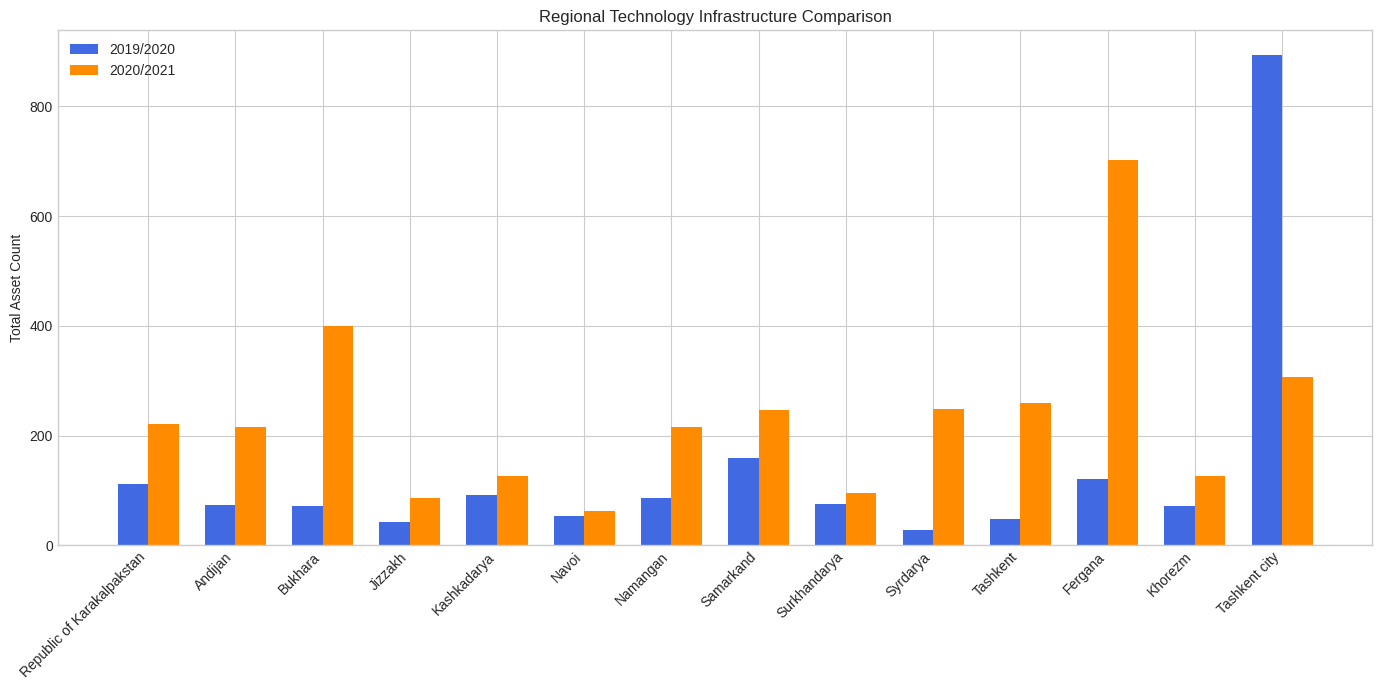

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('Info on Technology distribution csv.csv')

# Corrected: Exclude 'Name of Territories' from numeric conversion
cols_to_convert = df.columns[2:12] # Assuming 'Name of Territories' is at index 1, and numeric columns start from index 2
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Corrected: Summing only numeric columns for 2019 and 2020 totals
df['Total_2019'] = df[df.columns[2:7]].sum(axis=1)
df['Total_2020'] = df[df.columns[7:12]].sum(axis=1)

regions = df[df['Name of Territories'] != 'The Republic of Uzbekistan'].copy()

labels = regions['Name of Territories'].tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

rects1 = ax.bar(x - width/2, regions['Total_2019'], width, label='2019/2020', color='royalblue')
rects2 = ax.bar(x + width/2, regions['Total_2020'], width, label='2020/2021', color='darkorange')

ax.set_ylabel('Total Asset Count')
ax.set_title('Regional Technology Infrastructure Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()